In [1]:
import biolqm
import ginsim
from colomoto.minibn import BooleanNetwork
from colomoto_jupyter import tabulate
import pandas as pd # for displaying list of fixpoints
import pypint

This notebook has been executed using the docker image `colomoto/colomoto-docker:2019-12-19`

Downloading http://ginsim.org/sites/default/files/SuppMat_Model_Master_Model.zginml

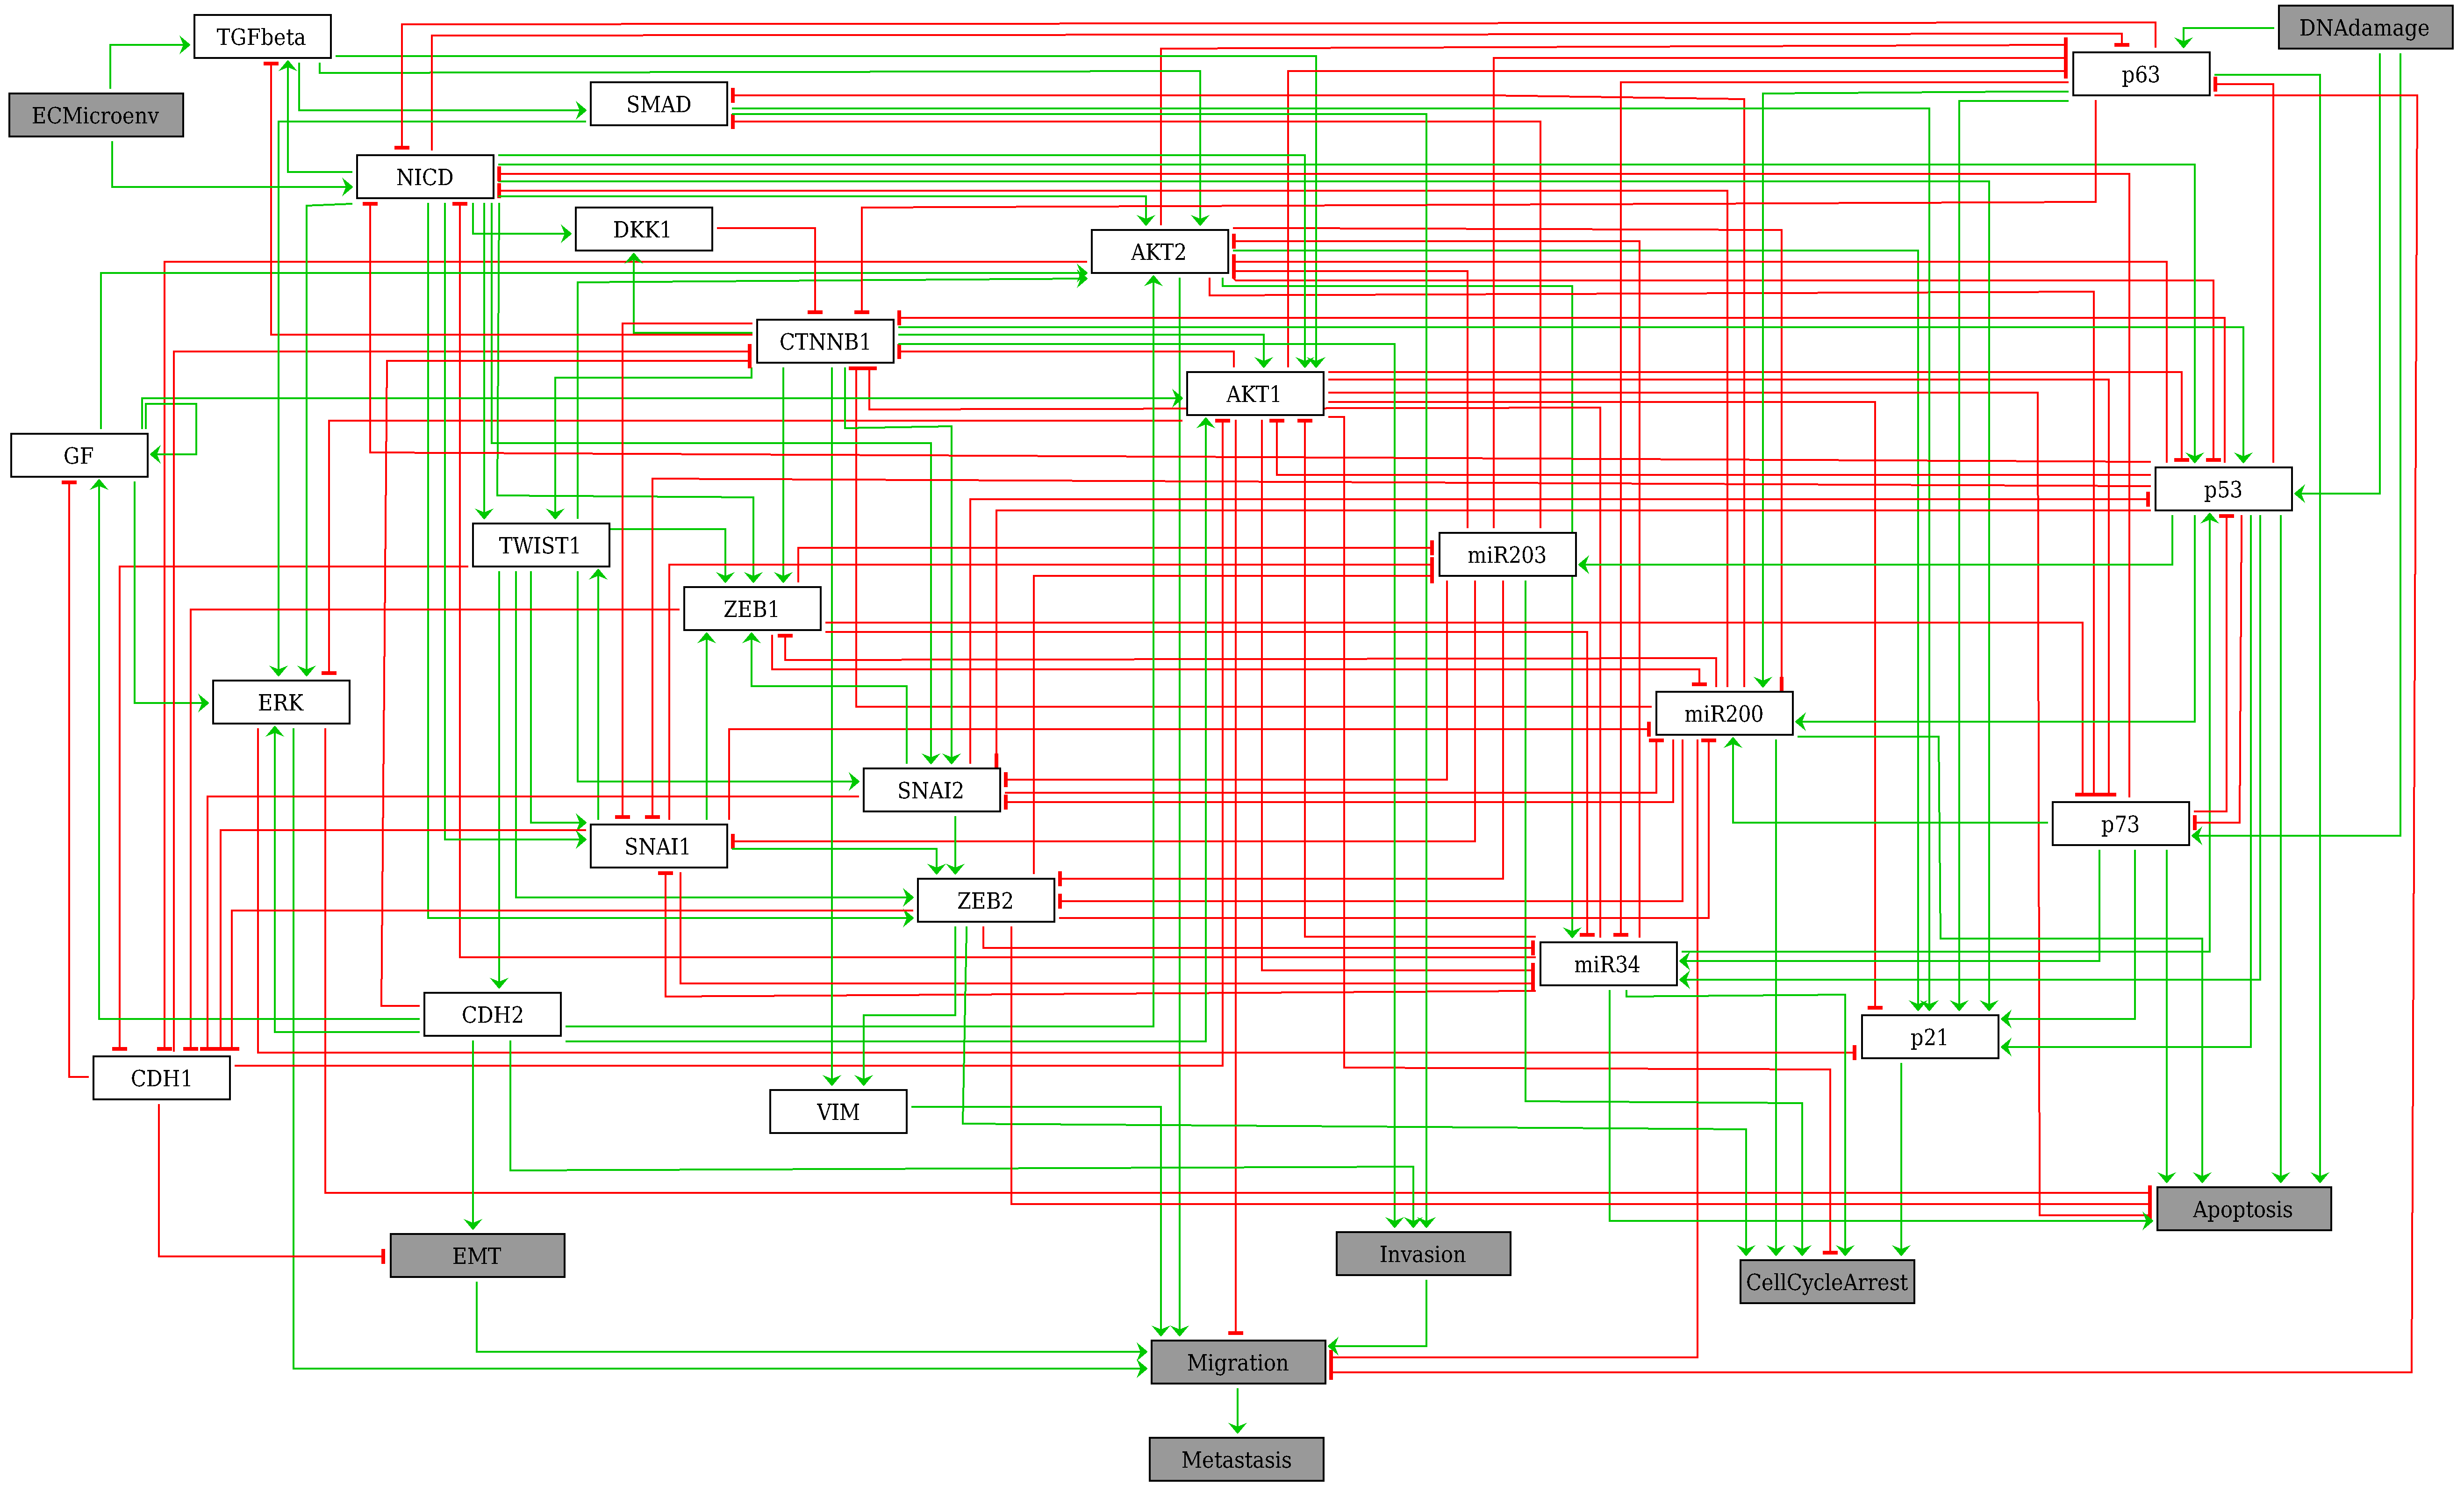

In [2]:
lrg = ginsim.load("http://ginsim.org/sites/default/files/SuppMat_Model_Master_Model.zginml")
ginsim.show(lrg)

In [3]:
lqm = ginsim.to_biolqm(lrg)
Test1 = biolqm.to_minibn(lqm)
Test1

AKT1 <- (!GF&!TGFbeta&!CDH1&!CDH2&CTNNB1&NICD&!p53&!miR34)|(!GF&!TGFbeta&!CDH1&CDH2&CTNNB1&!p53&!miR34)|(!GF&TGFbeta&!CDH1&CTNNB1&!p53&!miR34)|(GF&!CDH1&CTNNB1&!p53&!miR34)
AKT2 <- (!GF&!TGFbeta&!CDH2&TWIST1&NICD&!p53&!miR203&!miR34)|(!GF&!TGFbeta&CDH2&TWIST1&!p53&!miR203&!miR34)|(!GF&TGFbeta&TWIST1&!p53&!miR203&!miR34)|(GF&TWIST1&!p53&!miR203&!miR34)
Apoptosis <- (!ZEB2&!AKT1&!p63&!p53&!p73&!miR200&miR34&!ERK)|(!ZEB2&!AKT1&!p63&!p53&!p73&miR200&!ERK)|(!ZEB2&!AKT1&!p63&!p53&p73&!ERK)|(!ZEB2&!AKT1&!p63&p53&!ERK)|(!ZEB2&!AKT1&p63&!ERK)
CDH1 <- !TWIST1&!SNAI1&!SNAI2&!ZEB1&!ZEB2&!AKT2
CDH2 <- TWIST1
CTNNB1 <- !CDH1&!CDH2&!AKT1&!DKK1&!p63&!p53&!miR200&!miR34
CellCycleArrest <- (!p21&!ZEB2&!AKT1&!miR200&!miR203&miR34)|(!p21&!ZEB2&!AKT1&!miR200&miR203)|(!p21&!ZEB2&!AKT1&miR200)|(!p21&ZEB2&!AKT1)|(p21&!AKT1)
DKK1 <- (!CTNNB1&NICD)|CTNNB1
DNAdamage <- DNAdamage
ECMicroenv <- ECMicroenv
EMT <- !CDH1&CDH2
ERK <- (!GF&!CDH2&!AKT1&!NICD&SMAD)|(!GF&!CDH2&!AKT1&NICD)|(!GF&CDH2&!AKT1)|(GF&!AKT1)
GF <-

In [2]:
F = BooleanNetwork()
lr,ra,ai,rag,li = F.vars("lr", "ra", "ai","rag", "li")


In [3]:
F[lr] = ~rag|(lr&~ai)
F[ra] = ai&lr
F[ai] = li|(ai&~lr)
F[rag] = ra
F[li] = rag
#F[Light] = 0
F

ai <- li|(ai&!lr)
li <- rag
lr <- !rag|(lr&!ai)
ra <- ai&lr
rag <- ra

In [4]:
lqm = F.to_biolqm()

In [5]:
tabulate(biolqm.fixpoints(lqm))

<table>
<thead>
<tr><th style="text-align: right;">  </th><th style="text-align: right;">  ai</th><th style="text-align: right;">  li</th><th style="text-align: right;">  lr</th><th style="text-align: right;">  ra</th><th style="text-align: right;">  rag</th></tr>
</thead>
<tbody>
<tr><td style="text-align: right;"> 0</td><td style="text-align: right;">   0</td><td style="text-align: right;">   0</td><td style="text-align: right;">   1</td><td style="text-align: right;">   0</td><td style="text-align: right;">    0</td></tr>
</tbody>
</table>

In [11]:
def DecimalToBinary(num): 
  return "{0:b}".format(num).zfill(5)

    
attractor_lits = list()
DF_list = list()
fixpoints_counts = 0
fixpoints_lits = list() 

for x in range(32):
    trace = biolqm.trace(lqm , "-u synchronous -i "+DecimalToBinary(x))
    df = pd.DataFrame(trace)
    DF_list.append(df)
    #print(df)
    last_row= df.iloc[-1,:]
    final = str(last_row["ai"])+str(last_row["li"])+str(last_row["lr"])+str(last_row["ra"])+str(last_row["rag"])
    if(final == "00100"):
        fixpoints_counts +=1
        fixpoints_lits.append(df)  
    else: # attrctors
        df = df.applymap(str)
        attractor_lits.append(df)    

print("Attractors:"+ str(len(attractor_lits)))
print("Fixpoints:"+str(fixpoints_counts))


for items in fixpoints_lits:
        print(items)

Attractors:30
Fixpoints:2
   ai  li  lr  ra  rag
0   0   0   0   0    0
1   0   0   1   0    0
   ai  li  lr  ra  rag
0   0   0   1   0    0


In [9]:
def ToString(row_df):
    return pd.Series(row_df.fillna('').values.tolist()).str.cat(sep='') 

def FindBasin(index,attractor,attractor_lits): 
    matched_state =[] 
    global_attrator_size = len(attractor.index)
    total_count_basin =0
    total_loop_found = 0
    local_count_basin = 0
    for local_index, local_attractor_df in enumerate(attractor_lits):  # fetch each attractor (the local attractor)
           
            if(index == local_index): # skip scan to itself
                continue
            #else: 
                 #print("attractors:"+str(local_index))
            
            local_attrator_size = len(local_attractor_df.index)
            
            for local_row_index, local_row in local_attractor_df.iterrows():#get each row of the local attractor compare to the global row
                
                str_local_row =  ToString(local_row)
                 # Find loop ( if orbit exists then continue to next iteration)
                
                
                for global_row_index, global_row in attractor.iterrows():

                        count_found_loop = 0
                        str_global_row = ToString(global_row)
                        
                        # Count basin
                        #if(str_local_row in matched_state):
                                #if(count_found_loop > 1 ):
                                #    local_count_basin = local_count_basin - count_found_loop
                        #        continue
                        #else:
                        #    matched_state.append(str_local_row)
                        #    local_count_basin+=1
                            
                        if(str_global_row == str_local_row ): 
                           # check remaing
                            count_found_loop+=1
                            i = global_row_index
                            z = local_row_index
                            while(  ( z+1 < local_attrator_size and i+1 < global_attrator_size)
                                  and (ToString(local_attractor_df.iloc[z+1]) == ToString(attractor.iloc[i+1]))  ):
                                i+=1
                                z+=1
                                count_found_loop+=1
                                
                        if(count_found_loop > 1 ): # Loop Found  
                            #print(count_found_loop)
                            #total_loop_found +=1
                            #if(str_local_row in matched_state):
                            #     pass
                            #else: 
                                j = local_row_index   
                                #print("start index:"+str(local_row_index))
                                while(j >=0  ):  # check previous 
                                    local_row = ToString(local_attractor_df.iloc[j])
                                    #print(local_row)
                                    if(local_row not in matched_state): 
                                        matched_state.append(local_row)                
                                    j-=1                                         
                        else:       
                            pass
                           
    
    for global_row_index, global_row in attractor.iterrows():
        str_global_row = ToString(global_row)
        if(str_global_row in matched_state):
            pass
        else:
            matched_state.append(str_global_row)
        
    #print("total_loop_found:"+str(total_loop_found))
    #print("Array size:"+str(len(matched_state)))
    #matched_state = list(set(matched_state))
    total_count_basin = len(matched_state) # + (global_attrator_size-1)
    print("Basin list:")
    print(matched_state)
    return total_count_basin

def FindOrbit(attractor_df):
    global_attrator_size  = len(attractor_df.index)
    index_list = list()
    for  local_index, local_row in attractor_df.iterrows():
        global_row = ToString(local_row)
        count_found_loop = 0
        z = 0
        while(z < global_attrator_size  ):
            if(global_row == ToString(attractor_df.iloc[z])):
                index_list.append(z)
                count_found_loop+=1
            z+=1
        #print(index_list)
        if(count_found_loop > 1 ):
            print("orbit:"+str(index_list[-1]-index_list[-2]))

for index,attractor_df in enumerate(attractor_lits): 
    print("attractor index:"+str(index))
    print(attractor_df)
    allstates_count_row = attractor_df.shape[0]
    count_basin= FindBasin(index,attractor_df,attractor_lits)
    FindOrbit(attractor_df)        
    print("count_basin:"+str(count_basin))
    print("basin size:"+str((count_basin/32)*100) + "%")
    #print("allstates_count_row: "+str(allstates_count_row))
    print("---ends---")
 # print(DecimalToBinary(x))

attractor index:0
  ai li lr ra rag
0  0  0  0  0   1
1  0  1  0  0   0
2  1  0  1  0   0
3  0  0  1  1   0
4  0  0  1  0   1
5  0  1  1  0   0
6  1  0  1  0   0
Basin list:
['00101', '00010', '01100', '10100', '00110', '11000', '01001', '00011', '01000', '11001', '01011', '10000', '10001', '10011', '10111', '11011', '11110', '11111', '00001']
orbit:4
orbit:4
count_basin:19
basin size:59.375%
---ends---
attractor index:1
  ai li lr ra rag
0  0  0  0  1   0
1  0  0  1  0   1
2  0  1  1  0   0
3  1  0  1  0   0
4  0  0  1  1   0
5  0  0  1  0   1
Basin list:
['10100', '01000', '00001', '00110', '00101', '01100', '11000', '01001', '00011', '11001', '01011', '10000', '10001', '10011', '10111', '11011', '11110', '11111', '00010']
orbit:4
orbit:4
count_basin:19
basin size:59.375%
---ends---
attractor index:2
  ai li lr ra rag
0  0  0  0  1   1
1  0  1  0  0   1
2  1  1  0  0   0
3  1  0  1  0   0
4  0  0  1  1   0
5  0  0  1  0   1
6  0  1  1  0   0
7  1  0  1  0   0
Basin list:
['10100', '0

orbit:2
count_basin:7
basin size:21.875%
---ends---
attractor index:25
  ai li lr ra rag
0  1  1  0  1   1
1  1  1  0  0   1
2  1  1  0  0   0
3  1  0  1  0   0
4  0  0  1  1   0
5  0  0  1  0   1
6  0  1  1  0   0
7  1  0  1  0   0
Basin list:
['10100', '01000', '00001', '00110', '00101', '01100', '00010', '11000', '01001', '00011', '11001', '01011', '10000', '10001', '10011', '10111', '11110', '11011', '11111']
orbit:4
orbit:4
count_basin:19
basin size:59.375%
---ends---
attractor index:26
  ai li lr ra rag
0  1  1  1  0   0
1  1  0  1  1   0
2  0  0  1  1   1
3  0  1  1  0   1
4  1  1  1  0   0
Basin list:
['00111', '01101', '11100', '10110']
orbit:4
orbit:4
count_basin:4
basin size:12.5%
---ends---
attractor index:27
  ai li lr ra rag
0  1  1  1  0   1
1  1  1  0  1   0
2  1  0  1  0   1
3  0  1  0  1   0
4  1  0  1  0   1
Basin list:
['01010', '10101', '01110', '11101', '01111', '11010', '10010']
orbit:2
orbit:2
count_basin:7
basin size:21.875%
---ends---
attractor index:28
  ai l